In [1]:
# STEP 1: Install required libraries (run this cell FIRST, only need to do it once)
# This may take a few minutes - wait for it to finish before moving on
!pip install statsmodels prophet tensorflow scikit-learn matplotlib pandas numpy joblib


In [2]:
"""
DMart Sales Forecasting / Prediction
"""

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# ARIMA
from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

# LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [3]:
# ------------------------------
# SETTINGS
# ------------------------------
import os

# Use the folder where this notebook lives, regardless of where Jupyter was launched
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except:
    NOTEBOOK_DIR = os.getcwd()

DATA_DIR = os.path.join(NOTEBOOK_DIR, "datasets")   # CSV files live in datasets/
OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, "outputs_sales_forecasting")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TOP_N_SERIES = 5  # for ARIMA/Prophet/LSTM demo (to keep runtime reasonable)
VALIDATION_MONTHS = 3  # time-based validation window
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Using DATA_DIR:", DATA_DIR)
print("Saving outputs to:", OUTPUT_DIR)
print("DATA_DIR exists:", os.path.isdir(DATA_DIR))
print("Files found:", os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR) else "FOLDER NOT FOUND")


Using DATA_DIR: C:\Users\brend\Downloads\sales_project\datasets
Saving outputs to: C:\Users\brend\Downloads\sales_project\outputs_sales_forecasting
DATA_DIR exists: True
Files found: ['calendar.csv', 'inventory_weekly.csv', 'items.csv', 'item_categories.csv', 'outputs_sales_forecasting', 'promotions.csv', 'sales.csv', 'shops.csv']


In [4]:
# ------------------------------
# LOAD DATA
# ------------------------------
item_categories = pd.read_csv(os.path.join(DATA_DIR, "item_categories.csv"))
items = pd.read_csv(os.path.join(DATA_DIR, "items.csv"))
shops = pd.read_csv(os.path.join(DATA_DIR, "shops.csv"))
sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"))
calendar = pd.read_csv(os.path.join(DATA_DIR, "calendar.csv"))
promotions = pd.read_csv(os.path.join(DATA_DIR, "promotions.csv"))
inventory_weekly = pd.read_csv(os.path.join(DATA_DIR, "inventory_weekly.csv"))

print("\nLoaded shapes:")
print("item_categories:", item_categories.shape)
print("items:", items.shape)
print("shops:", shops.shape)
print("sales:", sales.shape)
print("calendar:", calendar.shape)
print("promotions:", promotions.shape)
print("inventory_weekly:", inventory_weekly.shape)



Loaded shapes:
item_categories: (100, 2)
items: (1500, 13)
shops: (50, 8)
sales: (168695, 13)
calendar: (1826, 12)
promotions: (1800, 9)
inventory_weekly: (261000, 7)


In [5]:
# ------------------------------
# PREPROCESSING
# ------------------------------

# Standardize column names
def standardize_cols(df):
    df.columns = [c.strip().lower() for c in df.columns]
    return df

item_categories = standardize_cols(item_categories)
items = standardize_cols(items)
shops = standardize_cols(shops)
sales = standardize_cols(sales)
calendar = standardize_cols(calendar)
promotions = standardize_cols(promotions)
inventory_weekly = standardize_cols(inventory_weekly)

# Parse and standardize date fields
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
calendar["date"] = pd.to_datetime(calendar["date"], errors="coerce")
promotions["start_date"] = pd.to_datetime(promotions["start_date"], errors="coerce")
promotions["end_date"] = pd.to_datetime(promotions["end_date"], errors="coerce")
shops["opening_date"] = pd.to_datetime(shops["opening_date"], errors="coerce")
inventory_weekly["week_ending_date"] = pd.to_datetime(inventory_weekly["week_ending_date"], errors="coerce")

# Drop rows with invalid date in critical tables
sales = sales.dropna(subset=["date"]).copy()
calendar = calendar.dropna(subset=["date"]).copy()

# Handle missing values

# Sales: critical numeric columns
for col in ["item_mrp_inr", "item_price_inr", "discount_pct", "item_cnt_day", "revenue_inr"]:
    if col in sales.columns:
        sales[col] = pd.to_numeric(sales[col], errors="coerce")

sales["discount_pct"] = sales["discount_pct"].fillna(0.0)
sales["is_promo"] = sales["is_promo"].fillna(0).astype(int)
sales["stockout_flag"] = sales["stockout_flag"].fillna(0).astype(int)

# Items: fill missing categorical with 'Unknown'
for col in ["brand", "tier", "pack_size_uom", "item_name"]:
    if col in items.columns:
        items[col] = items[col].fillna("Unknown")

# Shops
for col in ["shop_city", "shop_state", "shop_region", "store_type", "shop_name"]:
    if col in shops.columns:
        shops[col] = shops[col].fillna("Unknown")

# Calendar flags (ensure ints)
flag_cols = ["is_weekend", "is_national_holiday", "is_festive_season", "is_summer", "is_monsoon"]
for c in flag_cols:
    if c in calendar.columns:
        calendar[c] = calendar[c].fillna(0).astype(int)

# Promotions numeric
promotions["discount_pct"] = pd.to_numeric(promotions["discount_pct"], errors="coerce").fillna(0.0)
promotions["demand_uplift_mult"] = pd.to_numeric(promotions["demand_uplift_mult"], errors="coerce").fillna(1.0)

# Inventory numeric
for col in ["on_hand_qty", "reorder_point_qty", "supplier_lead_time_days"]:
    if col in inventory_weekly.columns:
        inventory_weekly[col] = pd.to_numeric(inventory_weekly[col], errors="coerce").fillna(0).astype(int)

# Validate referential integrity (FK checks)
missing_shop = set(sales["shop_id"].unique()) - set(shops["shop_id"].unique())
missing_item = set(sales["item_id"].unique()) - set(items["item_id"].unique())
missing_cat = set(items["item_category_id"].unique()) - set(item_categories["item_category_id"].unique())

print("\nReferential Integrity Checks:")
print("Missing shop_ids in shops:", len(missing_shop))
print("Missing item_ids in items:", len(missing_item))
print("Missing item_category_ids in item_categories:", len(missing_cat))

# If any missing, drop those rows
if len(missing_shop) > 0:
    sales = sales[~sales["shop_id"].isin(list(missing_shop))].copy()
if len(missing_item) > 0:
    sales = sales[~sales["item_id"].isin(list(missing_item))].copy()
if len(missing_cat) > 0:
    items = items[~items["item_category_id"].isin(list(missing_cat))].copy()

# Outlier treatment (cap extreme values)
def cap_outliers(s, low_q=0.01, high_q=0.99):
    lo = s.quantile(low_q)
    hi = s.quantile(high_q)
    return s.clip(lo, hi)

sales["item_cnt_day"] = cap_outliers(sales["item_cnt_day"])
sales["item_price_inr"] = cap_outliers(sales["item_price_inr"])
sales["item_mrp_inr"] = cap_outliers(sales["item_mrp_inr"])
sales["revenue_inr"] = cap_outliers(sales["revenue_inr"])

# Basic sanity checks
sales = sales[sales["item_cnt_day"] >= 0].copy()
sales = sales[sales["item_price_inr"] > 0].copy()



Referential Integrity Checks:
Missing shop_ids in shops: 0
Missing item_ids in items: 0
Missing item_category_ids in item_categories: 0


In [6]:
# ------------------------------
# FEATURE ENGINEERING (monthly level for forecasting)
# ------------------------------

sales["year"] = sales["date"].dt.year
sales["month"] = sales["date"].dt.month
sales["year_month"] = sales["date"].dt.to_period("M").astype(str)

# Aggregate to monthly item-shop level
monthly = sales.groupby(["year_month", "year", "month", "shop_id", "item_id"], as_index=False).agg(
    qty=("item_cnt_day", "sum"),
    avg_price=("item_price_inr", "mean"),
    avg_mrp=("item_mrp_inr", "mean"),
    promo_days=("is_promo", "sum"),
    stockout_days=("stockout_flag", "sum"),
    revenue=("revenue_inr", "sum")
)

# Merge items, categories, shops
monthly = monthly.merge(items[["item_id", "item_category_id", "brand", "tier", "mrp_inr", "unit_cost_inr", "is_perishable"]], on="item_id", how="left")
monthly = monthly.merge(item_categories, on="item_category_id", how="left")
monthly = monthly.merge(shops[["shop_id", "shop_city", "shop_state", "shop_region", "store_type", "store_size_sqft"]], on="shop_id", how="left")

# Calendar monthly features
calendar["year_month"] = calendar["date"].dt.to_period("M").astype(str)
cal_month = calendar.groupby("year_month", as_index=False).agg(
    holiday_days=("is_national_holiday", "sum"),
    weekend_days=("is_weekend", "sum"),
    festive_days=("is_festive_season", "sum"),
    summer_days=("is_summer", "sum"),
    monsoon_days=("is_monsoon", "sum"),
    days_in_month=("date", "count")
)
monthly = monthly.merge(cal_month, on="year_month", how="left")

# Promotion impact indicators
promotions = promotions.dropna(subset=["start_date", "end_date"]).copy()
promotions["start_month"] = promotions["start_date"].dt.to_period("M").astype(str)
promotions["end_month"] = promotions["end_date"].dt.to_period("M").astype(str)

promo_m = []
for _, r in promotions.iterrows():
    months = pd.period_range(r["start_date"].to_period("M"), r["end_date"].to_period("M"), freq="M").astype(str)
    for ym in months:
        promo_m.append((ym, int(r["shop_id"]), int(r["item_category_id"]), float(r["discount_pct"]), float(r["demand_uplift_mult"])))

promo_m = pd.DataFrame(promo_m, columns=["year_month", "shop_id", "item_category_id", "promo_discount_pct", "promo_uplift"])
promo_m_agg = promo_m.groupby(["year_month", "shop_id", "item_category_id"], as_index=False).agg(
    promo_discount_pct=("promo_discount_pct", "mean"),
    promo_uplift=("promo_uplift", "mean"),
    promo_campaigns=("promo_uplift", "count")
)
monthly = monthly.merge(promo_m_agg, on=["year_month", "shop_id", "item_category_id"], how="left")

monthly["promo_discount_pct"] = monthly["promo_discount_pct"].fillna(0.0)
monthly["promo_uplift"] = monthly["promo_uplift"].fillna(1.0)
monthly["promo_campaigns"] = monthly["promo_campaigns"].fillna(0).astype(int)

# Stock availability signals (inventory)
inventory_weekly["year_month"] = inventory_weekly["week_ending_date"].dt.to_period("M").astype(str)
inv_month = inventory_weekly.groupby(["year_month", "shop_id", "item_id"], as_index=False).agg(
    avg_on_hand=("on_hand_qty", "mean"),
    avg_reorder_point=("reorder_point_qty", "mean"),
    avg_lead_time=("supplier_lead_time_days", "mean"),
    inv_snapshots=("inventory_snapshot_id", "count")
)
monthly = monthly.merge(inv_month, on=["year_month", "shop_id", "item_id"], how="left")
monthly["avg_on_hand"] = monthly["avg_on_hand"].fillna(0.0)
monthly["avg_reorder_point"] = monthly["avg_reorder_point"].fillna(0.0)
monthly["avg_lead_time"] = monthly["avg_lead_time"].fillna(0.0)
monthly["inv_snapshots"] = monthly["inv_snapshots"].fillna(0).astype(int)

# Price elasticity features
monthly["price_ratio"] = (monthly["avg_price"] / monthly["avg_mrp"]).replace([np.inf, -np.inf], np.nan).fillna(1.0)
monthly["price_discount_pct"] = (1.0 - monthly["price_ratio"]).clip(-1, 1)

# Lag features and rolling statistics
monthly = monthly.sort_values(["shop_id", "item_id", "year", "month"]).reset_index(drop=True)

monthly["qty_lag_1"] = monthly.groupby(["shop_id", "item_id"])["qty"].shift(1)
monthly["qty_lag_2"] = monthly.groupby(["shop_id", "item_id"])["qty"].shift(2)
monthly["qty_lag_3"] = monthly.groupby(["shop_id", "item_id"])["qty"].shift(3)

monthly["qty_roll_3"] = monthly.groupby(["shop_id", "item_id"])["qty"].transform(lambda s: s.shift(1).rolling(3).mean())
monthly["qty_roll_6"] = monthly.groupby(["shop_id", "item_id"])["qty"].transform(lambda s: s.shift(1).rolling(6).mean())

monthly["price_lag_1"] = monthly.groupby(["shop_id", "item_id"])["avg_price"].shift(1)
monthly["price_change_pct"] = ((monthly["avg_price"] - monthly["price_lag_1"]) / (monthly["price_lag_1"] + 1e-6)).clip(-2, 2)

# Fill lags/rolls
for c in ["qty_lag_1", "qty_lag_2", "qty_lag_3", "qty_roll_3", "qty_roll_6", "price_lag_1"]:
    monthly[c] = monthly[c].fillna(0.0)

monthly["qty_trend"] = monthly["qty_roll_3"] - monthly["qty_roll_6"]
monthly["promo_intensity"] = (monthly["promo_days"] / monthly["days_in_month"]).fillna(0.0).clip(0, 1)

# Target: next month qty
monthly["qty_next_month"] = monthly.groupby(["shop_id", "item_id"])["qty"].shift(-1)
monthly = monthly.dropna(subset=["qty_next_month"]).copy()

print("\nMonthly modeling dataset:", monthly.shape)
monthly.to_csv(os.path.join(OUTPUT_DIR, "monthly_features.csv"), index=False)



Monthly modeling dataset: (136398, 48)



Generating EDA plots...


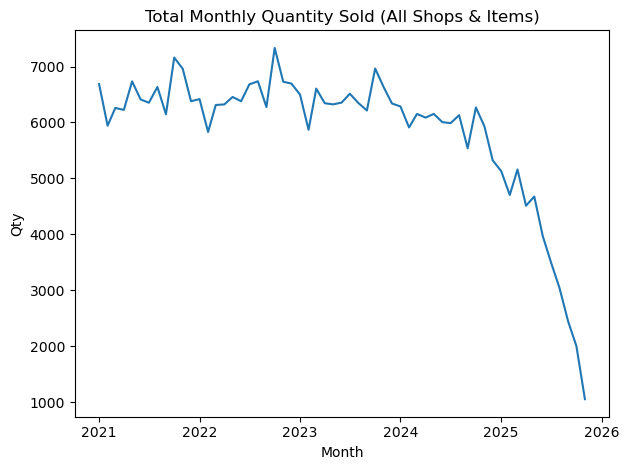

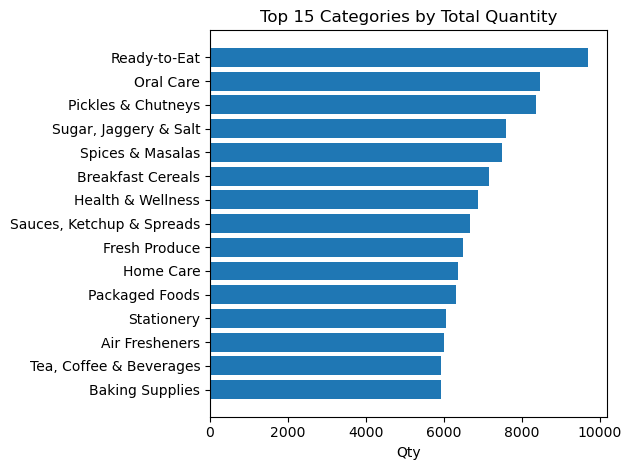

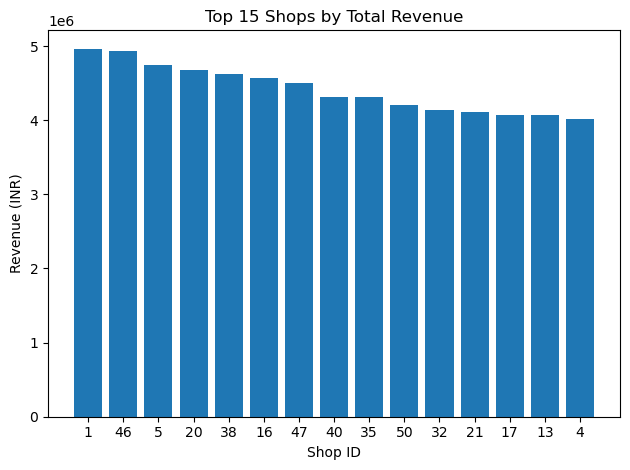

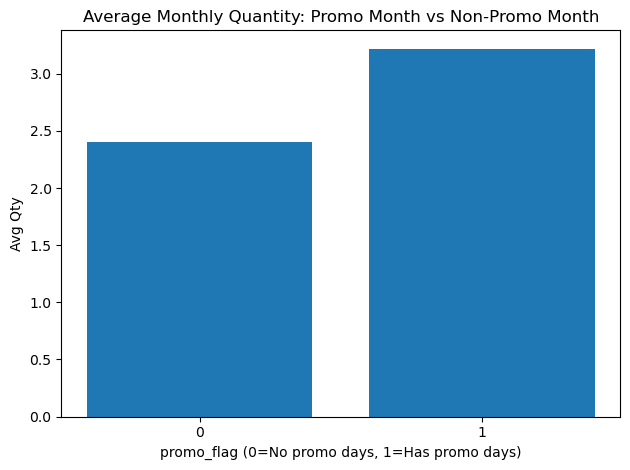

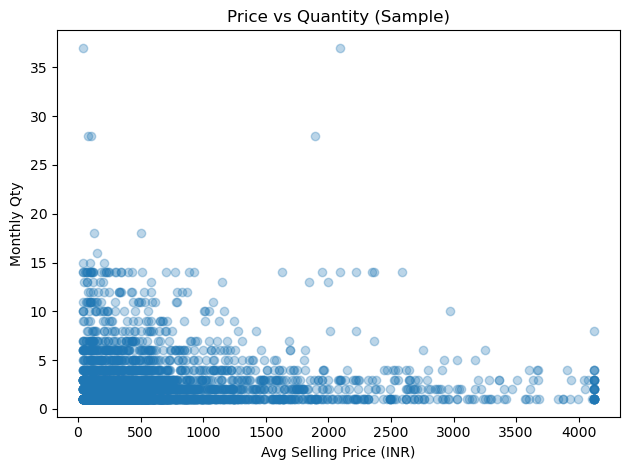

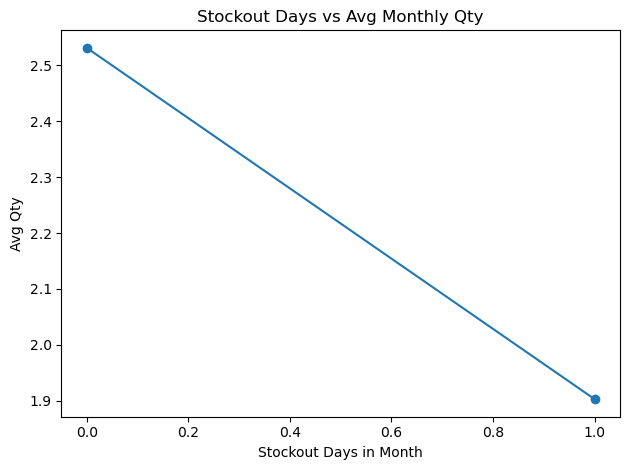

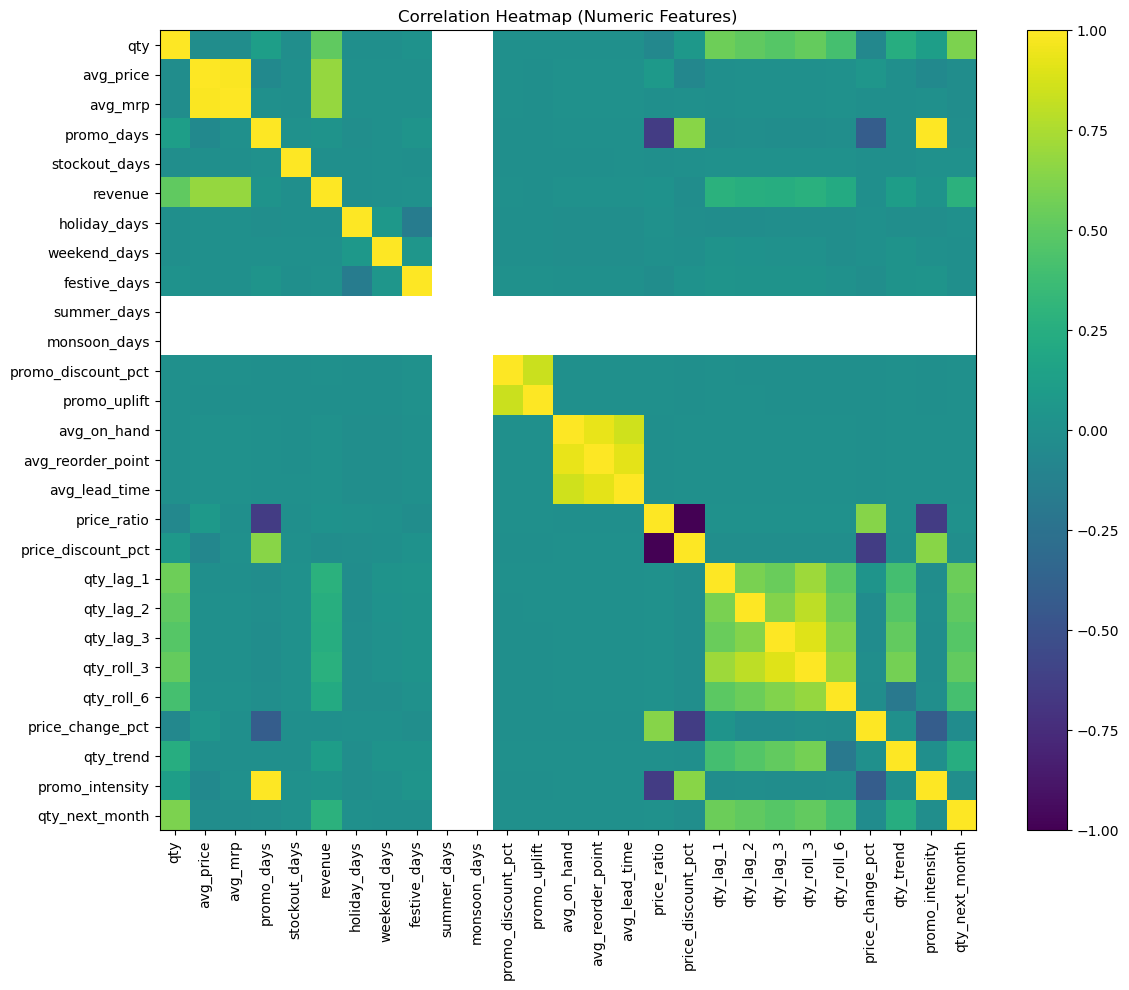

EDA plots saved in: C:\Users\brend\Downloads\sales_project\outputs_sales_forecasting


In [7]:
# ------------------------------
# EDA (plots saved to OUTPUT_DIR)
# ------------------------------
print("\nGenerating EDA plots...")

# Trend & seasonality (total monthly qty)
tot = monthly.groupby("year_month", as_index=False)["qty"].sum()
plt.figure()
plt.plot(pd.to_datetime(tot["year_month"]), tot["qty"])
plt.title("Total Monthly Quantity Sold (All Shops & Items)")
plt.xlabel("Month")
plt.ylabel("Qty")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_total_monthly_qty.png"))
plt.show()
plt.close()

# Category contribution (top 15 categories by qty)
cat_qty = monthly.groupby("item_category_name", as_index=False)["qty"].sum().sort_values("qty", ascending=False).head(15)
plt.figure()
plt.barh(cat_qty["item_category_name"][::-1], cat_qty["qty"][::-1])
plt.title("Top 15 Categories by Total Quantity")
plt.xlabel("Qty")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_top_categories.png"))
plt.show()
plt.close()

# Shop contribution (top 15 shops by revenue)
shop_rev = monthly.groupby("shop_id", as_index=False)["revenue"].sum().sort_values("revenue", ascending=False).head(15)
plt.figure()
plt.bar(shop_rev["shop_id"].astype(str), shop_rev["revenue"])
plt.title("Top 15 Shops by Total Revenue")
plt.xlabel("Shop ID")
plt.ylabel("Revenue (INR)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_top_shops_revenue.png"))
plt.show()
plt.close()

# Promo vs Non-Promo (avg qty)
monthly["promo_flag"] = (monthly["promo_days"] > 0).astype(int)
promo_cmp = monthly.groupby("promo_flag", as_index=False)["qty"].mean()
plt.figure()
plt.bar(promo_cmp["promo_flag"].astype(str), promo_cmp["qty"])
plt.title("Average Monthly Quantity: Promo Month vs Non-Promo Month")
plt.xlabel("promo_flag (0=No promo days, 1=Has promo days)")
plt.ylabel("Avg Qty")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_promo_vs_nonpromo.png"))
plt.show()
plt.close()

# Price vs Qty scatter (sampled for readability)
sample = monthly.sample(min(4000, len(monthly)), random_state=RANDOM_SEED)
plt.figure()
plt.scatter(sample["avg_price"], sample["qty"], alpha=0.3)
plt.title("Price vs Quantity (Sample)")
plt.xlabel("Avg Selling Price (INR)")
plt.ylabel("Monthly Qty")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_price_vs_qty.png"))
plt.show()
plt.close()

# Stockout impact
stock_cmp = monthly.groupby("stockout_days", as_index=False)["qty"].mean().sort_values("stockout_days").head(15)
plt.figure()
plt.plot(stock_cmp["stockout_days"], stock_cmp["qty"], marker="o")
plt.title("Stockout Days vs Avg Monthly Qty")
plt.xlabel("Stockout Days in Month")
plt.ylabel("Avg Qty")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_stockout_impact.png"))
plt.show()
plt.close()

# Correlation heatmap (numeric features)
num_cols = [
    "qty", "avg_price", "avg_mrp", "promo_days", "stockout_days", "revenue",
    "holiday_days", "weekend_days", "festive_days", "summer_days", "monsoon_days",
    "promo_discount_pct", "promo_uplift", "avg_on_hand",
    "avg_reorder_point", "avg_lead_time", "price_ratio", "price_discount_pct",
    "qty_lag_1", "qty_lag_2", "qty_lag_3", "qty_roll_3", "qty_roll_6",
    "price_change_pct", "qty_trend", "promo_intensity", "qty_next_month"
]
num_cols = [c for c in num_cols if c in monthly.columns]
corr = monthly[num_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_correlation_heatmap.png"))
plt.show()
plt.close()

print("EDA plots saved in:", OUTPUT_DIR)


In [8]:
# ------------------------------
# MODELING DATA PREP (Encoding + Scaling)
# ------------------------------

feature_cols = [
    "avg_price", "avg_mrp", "promo_days", "stockout_days", "revenue",
    "holiday_days", "weekend_days", "festive_days", "summer_days", "monsoon_days",
    "promo_discount_pct", "promo_uplift", "promo_campaigns",
    "avg_on_hand", "avg_reorder_point", "avg_lead_time", "inv_snapshots",
    "price_ratio", "price_discount_pct", "price_change_pct",
    "qty_lag_1", "qty_lag_2", "qty_lag_3", "qty_roll_3", "qty_roll_6", "qty_trend",
    "promo_intensity",
    "store_size_sqft"
]

cat_cols = ["shop_city", "shop_state", "shop_region", "store_type", "brand", "tier", "item_category_name"]

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in monthly.columns]
cat_cols = [c for c in cat_cols if c in monthly.columns]

model_df = monthly[["year_month", "shop_id", "item_id", "qty_next_month"] + feature_cols + cat_cols].copy()

# One-hot encode categorical
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

# Time-based split: last VALIDATION_MONTHS months as validation
all_months = sorted(model_df["year_month"].unique())
val_months = all_months[-VALIDATION_MONTHS:]
train_df = model_df[~model_df["year_month"].isin(val_months)].copy()   # NOTE: ~ means NOT in val
val_df = model_df[model_df["year_month"].isin(val_months)].copy()

X_train = train_df.drop(columns=["year_month", "shop_id", "item_id", "qty_next_month"])
y_train = train_df["qty_next_month"].values
X_val = val_df.drop(columns=["year_month", "shop_id", "item_id", "qty_next_month"])
y_val = val_df["qty_next_month"].values

# Fill NaN with 0
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Scale numeric
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler.joblib"))


['C:\\Users\\brend\\Downloads\\sales_project\\outputs_sales_forecasting\\scaler.joblib']

In [9]:
# ------------------------------
# TRAIN REGRESSION MODELS + COMPARE
# ------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.where(np.abs(y_true) < 1e-6, 1.0, np.abs(y_true))
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

print("\nTraining Regression Models...")

results = []

# Linear Regression (scaled)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_val_scaled)
results.append(("LinearRegression", rmse(y_val, pred_lr), mean_absolute_error(y_val, pred_lr), mape(y_val, pred_lr)))
joblib.dump(lr, os.path.join(OUTPUT_DIR, "model_linear_regression.joblib"))

# RandomForestRegressor
rf = RandomForestRegressor(n_estimators=220, random_state=RANDOM_SEED, n_jobs=-1, max_depth=None)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
results.append(("RandomForestRegressor", rmse(y_val, pred_rf), mean_absolute_error(y_val, pred_rf), mape(y_val, pred_rf)))
joblib.dump(rf, os.path.join(OUTPUT_DIR, "model_random_forest.joblib"))

# GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=RANDOM_SEED)
gbr.fit(X_train, y_train)
pred_gbr = gbr.predict(X_val)
results.append(("GradientBoostingRegressor", rmse(y_val, pred_gbr), mean_absolute_error(y_val, pred_gbr), mape(y_val, pred_gbr)))
joblib.dump(gbr, os.path.join(OUTPUT_DIR, "model_gradient_boosting.joblib"))

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "MAPE_%"]).sort_values("RMSE")
print("\nModel Comparison (Regression):")
print(results_df)
results_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_regression.csv"), index=False)



Training Regression Models...

Model Comparison (Regression):
                       Model      RMSE       MAE     MAPE_%
1      RandomForestRegressor  1.938137  1.274922  62.812319
2  GradientBoostingRegressor  1.960560  1.273569  61.702738
0           LinearRegression  2.010432  1.371989  72.491319


In [10]:
# ------------------------------
# TIME-SERIES MODELS (ARIMA, Prophet, LSTM) on SELECTED SERIES
# ------------------------------

series_rank = monthly.groupby(["shop_id", "item_id"], as_index=False)["qty"].sum().sort_values("qty", ascending=False)
top_pairs = series_rank.head(TOP_N_SERIES)[["shop_id", "item_id"]].values.tolist()

def get_series(shop_id, item_id):
    df = monthly[(monthly["shop_id"]==shop_id) & (monthly["item_id"]==item_id)].copy()
    df = df.sort_values(["year", "month"])
    df["ds"] = pd.to_datetime(df["year_month"])
    df["y"] = df["qty"].astype(float)
    return df[["ds", "y", "avg_price", "price_ratio", "promo_intensity", "festive_days", "holiday_days", "stockout_days"]].copy()

# ARIMA
arima_scores = []
print("\nARIMA Forecasting (Top series)...")
for (sid, iid) in top_pairs:
    s = get_series(sid, iid)
    if len(s) < 18:
        continue
    s_train = s.iloc[:-VALIDATION_MONTHS].copy()
    s_val = s.iloc[-VALIDATION_MONTHS:].copy()
    try:
        # Set a proper monthly DatetimeIndex so ARIMA can forecast correctly
        arima_train = s_train.set_index(pd.DatetimeIndex(s_train["ds"]))
        arima_train.index.freq = "MS"   # month-start frequency
        model = ARIMA(arima_train["y"], order=(1,1,1))
        fit = model.fit()
        forecast = fit.forecast(steps=VALIDATION_MONTHS)
        score = rmse(s_val["y"].values, forecast.values)
        arima_scores.append((sid, iid, score))
        joblib.dump(fit, os.path.join(OUTPUT_DIR, f"arima_shop{sid}_item{iid}.pkl"))
    except Exception as e:
        print("ARIMA failed for shop", sid, "item", iid, "->", str(e))

if len(arima_scores) > 0:
    arima_df = pd.DataFrame(arima_scores, columns=["shop_id", "item_id", "RMSE"]).sort_values("RMSE")
    arima_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_arima_top_series.csv"), index=False)
    print(arima_df.head(10))

# Prophet
prophet_scores = []
print("\nProphet Forecasting (Top series)...")
for (sid, iid) in top_pairs:
    s = get_series(sid, iid)
    if len(s) < 18:
        continue
    s_train = s.iloc[:-VALIDATION_MONTHS].copy()
    s_val = s.iloc[-VALIDATION_MONTHS:].copy()
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    for reg in ["price_ratio", "promo_intensity", "festive_days", "holiday_days", "stockout_days"]:
        m.add_regressor(reg)
    try:
        m.fit(s_train.rename(columns={"ds":"ds", "y":"y"}))
        future = s_val.rename(columns={"ds":"ds", "y":"y"}).copy()
        fcst = m.predict(future[["ds", "price_ratio", "promo_intensity", "festive_days", "holiday_days", "stockout_days"]])
        yhat = fcst["yhat"].values
        score = rmse(s_val["y"].values, yhat)
        prophet_scores.append((sid, iid, score))
        joblib.dump(m, os.path.join(OUTPUT_DIR, f"prophet_shop{sid}_item{iid}.pkl"))
    except Exception as e:
        print("Prophet failed for shop", sid, "item", iid, "->", str(e))

if len(prophet_scores) > 0:
    prophet_df = pd.DataFrame(prophet_scores, columns=["shop_id", "item_id", "RMSE"]).sort_values("RMSE")
    prophet_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_prophet_top_series.csv"), index=False)
    print(prophet_df.head(10))


# LSTM (demo on TOTAL sales series to keep runtime manageable)
lstm_rmse = None
print("\nLSTM Forecasting (Total monthly sales series demo)...")
total_series = monthly.groupby("year_month", as_index=False)["qty"].sum().sort_values("year_month")
total_series["ds"] = pd.to_datetime(total_series["year_month"])
y = total_series["qty"].values.astype("float32")

y_min, y_max = y.min(), y.max()
y_scaled = (y - y_min) / (y_max - y_min + 1e-6)

lookback = 12
X_seq = []
y_seq = []
for i in range(lookback, len(y_scaled)):
    X_seq.append(y_scaled[i-lookback:i])
    y_seq.append(y_scaled[i])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

X_train_seq = X_seq[:-VALIDATION_MONTHS]
y_train_seq = y_seq[:-VALIDATION_MONTHS]
X_val_seq = X_seq[-VALIDATION_MONTHS:]
y_val_seq = y_seq[-VALIDATION_MONTHS:]

model = Sequential()
model.add(LSTM(64, input_shape=(lookback, 1)))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse")

model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=16, verbose=0)
pred = model.predict(X_val_seq).reshape(-1)

pred_inv = pred * (y_max - y_min + 1e-6) + y_min
y_val_inv = y_val_seq * (y_max - y_min + 1e-6) + y_min
lstm_rmse = rmse(y_val_inv, pred_inv)

model.save(os.path.join(OUTPUT_DIR, "lstm_total_sales_model.keras"))
print("LSTM RMSE (total series):", lstm_rmse)



ARIMA Forecasting (Top series)...
ARIMA failed for shop 25 item 76 -> Inferred frequency None from passed values does not conform to passed frequency MS

Prophet Forecasting (Top series)...


15:59:49 - cmdstanpy - INFO - Chain [1] start processing
15:59:54 - cmdstanpy - INFO - Chain [1] done processing


   shop_id  item_id       RMSE
0       25       76  67.080574

LSTM Forecasting (Total monthly sales series demo)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
LSTM RMSE (total series): 2797.4707326440434


In [11]:
# ------------------------------
# NEXT-MONTH FORECASTING TOOL (multi products & stores)
# ------------------------------
print("\nGenerating Next-Month Forecasts (Regression best model)...")

best_reg_model_name = results_df.iloc[0]["Model"]
if best_reg_model_name == "LinearRegression":
    best_model = lr
    use_scaled = True
elif best_reg_model_name == "RandomForestRegressor":
    best_model = rf
    use_scaled = False
else:
    best_model = gbr
    use_scaled = False

latest_month = sorted(monthly["year_month"].unique())[-1]
latest_rows = model_df[model_df["year_month"] == latest_month].copy()

X_latest = latest_rows.drop(columns=["year_month", "shop_id", "item_id", "qty_next_month"])
X_latest = X_latest.replace([np.inf, -np.inf], np.nan).fillna(0.0)
if use_scaled:
    X_latest_use = scaler.transform(X_latest)
    pred_next = best_model.predict(X_latest_use)
else:
    pred_next = best_model.predict(X_latest)

forecast_next = latest_rows[["shop_id", "item_id"]].copy()
forecast_next["pred_qty_next_month"] = np.maximum(0, pred_next)
forecast_next = forecast_next.merge(items[["item_id", "item_name", "item_category_id", "unit_cost_inr", "mrp_inr"]], on="item_id", how="left")
forecast_next = forecast_next.merge(shops[["shop_id", "shop_city", "shop_state", "shop_region"]], on="shop_id", how="left")
forecast_next = forecast_next.sort_values("pred_qty_next_month", ascending=False)

forecast_next.to_csv(os.path.join(OUTPUT_DIR, "forecast_next_month_shop_item.csv"), index=False)
print("Saved: forecast_next_month_shop_item.csv")



Generating Next-Month Forecasts (Regression best model)...
Saved: forecast_next_month_shop_item.csv


In [12]:
# ------------------------------
# MONTHLY & YEARLY FORECAST TOOL (item-level, aggregated)
# ------------------------------
print("\nGenerating Item-Level Monthly & Yearly Forecasts (aggregation)...")

item_forecast = forecast_next.groupby("item_id", as_index=False)["pred_qty_next_month"].sum()
item_forecast = item_forecast.merge(items[["item_id", "item_name", "item_category_id"]], on="item_id", how="left")
item_forecast = item_forecast.sort_values("pred_qty_next_month", ascending=False)
item_forecast.to_csv(os.path.join(OUTPUT_DIR, "forecast_next_month_items.csv"), index=False)

item_forecast["pred_qty_next_year"] = item_forecast["pred_qty_next_month"] * 12.0
item_forecast.to_csv(os.path.join(OUTPUT_DIR, "forecast_items_month_and_year.csv"), index=False)
print("Saved: forecast_items_month_and_year.csv")



Generating Item-Level Monthly & Yearly Forecasts (aggregation)...
Saved: forecast_items_month_and_year.csv


In [13]:
# ------------------------------
# PROFIT-MAKING SHOPS (descending order)
# ------------------------------
print("\nCalculating Profit by Shop (descending)...")

monthly["cost_est"] = monthly["unit_cost_inr"].fillna(0.0) * monthly["qty"]
monthly["profit_est"] = monthly["revenue"] - monthly["cost_est"]

shop_profit = monthly.groupby("shop_id", as_index=False).agg(
    total_revenue=("revenue", "sum"),
    total_cost=("cost_est", "sum"),
    total_profit=("profit_est", "sum"),
    total_qty=("qty", "sum")
).merge(shops[["shop_id", "shop_city", "shop_state", "shop_region"]], on="shop_id", how="left")

shop_profit = shop_profit.sort_values("total_profit", ascending=False)
shop_profit.to_csv(os.path.join(OUTPUT_DIR, "profit_ranking_shops.csv"), index=False)
print("Saved: profit_ranking_shops.csv")



Calculating Profit by Shop (descending)...
Saved: profit_ranking_shops.csv


In [14]:
# ------------------------------
# WHAT-IF SIMULATION MODULE (price increase scenario)
# ------------------------------
print("\nRunning What-if Simulation: Item price increases by 10% next quarter...")

elasticity = -0.25
price_increase = 0.10

whatif = forecast_next.copy()
whatif["whatif_price_up_pct"] = price_increase
whatif["whatif_qty_multiplier"] = 1.0 + elasticity * price_increase
whatif["whatif_pred_qty_next_month"] = whatif["pred_qty_next_month"] * whatif["whatif_qty_multiplier"]

whatif["whatif_new_price"] = whatif["mrp_inr"].fillna(whatif["mrp_inr"].median()) * (1.0 + price_increase)
whatif["whatif_revenue_next_month"] = whatif["whatif_new_price"] * whatif["whatif_pred_qty_next_month"]
whatif.to_csv(os.path.join(OUTPUT_DIR, "whatif_price_increase_10pct.csv"), index=False)
print("Saved: whatif_price_increase_10pct.csv")



Running What-if Simulation: Item price increases by 10% next quarter...
Saved: whatif_price_increase_10pct.csv


In [15]:
# ------------------------------
# INVENTORY & SUPPLY CHAIN OPTIMIZATION
# ------------------------------
print("\nInventory Optimization Signals...")

inv_latest_month = sorted(inventory_weekly["year_month"].dropna().unique())[-1] if "year_month" in inventory_weekly.columns else None
inv_last = inv_month.copy()
if inv_latest_month is not None:
    inv_last = inv_month[inv_month["year_month"] == inv_latest_month].copy()

inv_plan = forecast_next.merge(inv_last, on=["shop_id", "item_id"], how="left")
inv_plan["avg_on_hand"] = inv_plan["avg_on_hand"].fillna(0.0)
inv_plan["avg_lead_time"] = inv_plan["avg_lead_time"].fillna(7.0)
inv_plan["safety_stock"] = (0.15 * inv_plan["pred_qty_next_month"]).clip(0, None)
inv_plan["reorder_qty_suggested"] = (inv_plan["pred_qty_next_month"] + inv_plan["safety_stock"] - inv_plan["avg_on_hand"]).clip(0, None)
inv_plan = inv_plan.sort_values("reorder_qty_suggested", ascending=False)

inv_plan.to_csv(os.path.join(OUTPUT_DIR, "inventory_reorder_plan_next_month.csv"), index=False)
print("Saved: inventory_reorder_plan_next_month.csv")



Inventory Optimization Signals...
Saved: inventory_reorder_plan_next_month.csv


In [16]:
# ------------------------------
# CLASSIFICATION: SALES CATEGORY (region-wise)
# ------------------------------
print("\nClassification: Sales Categorization (Low/Medium/High) region-wise...")

cls_df = monthly.copy()
q1 = cls_df["qty"].quantile(0.33)
q2 = cls_df["qty"].quantile(0.66)

def to_class(x):
    if x <= q1:
        return "LOW"
    elif x <= q2:
        return "MEDIUM"
    else:
        return "HIGH"

cls_df["sales_class"] = cls_df["qty"].apply(to_class)

cls_features = ["avg_price", "promo_intensity", "holiday_days", "festive_days", "stockout_days", "price_ratio", "avg_on_hand", "store_size_sqft"]
cls_features = [c for c in cls_features if c in cls_df.columns]

cls_model_df = cls_df[cls_features + ["shop_region", "sales_class"]].copy()
cls_model_df = pd.get_dummies(cls_model_df, columns=["shop_region"], drop_first=True)

Xc = cls_model_df.drop(columns=["sales_class"])
yc = cls_model_df["sales_class"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_SEED, stratify=yc)
clf = RandomForestClassifier(n_estimators=220, random_state=RANDOM_SEED, n_jobs=-1)
clf.fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)

print("Accuracy:", accuracy_score(yc_test, yc_pred))
print("\nClassification Report:\n", classification_report(yc_test, yc_pred))
joblib.dump(clf, os.path.join(OUTPUT_DIR, "model_sales_classification_rf.joblib"))

cm = confusion_matrix(yc_test, yc_pred, labels=["LOW", "MEDIUM", "HIGH"])
cm_df = pd.DataFrame(cm, index=["LOW", "MEDIUM", "HIGH"], columns=["LOW", "MEDIUM", "HIGH"])
cm_df.to_csv(os.path.join(OUTPUT_DIR, "classification_confusion_matrix.csv"), index=True)



Classification: Sales Categorization (Low/Medium/High) region-wise...
Accuracy: 0.3994868035190616

Classification Report:
               precision    recall  f1-score   support

        HIGH       0.35      0.31      0.33      8406
         LOW       0.46      0.60      0.52     12162
      MEDIUM       0.25      0.15      0.19      6712

    accuracy                           0.40     27280
   macro avg       0.35      0.35      0.35     27280
weighted avg       0.37      0.40      0.38     27280



In [17]:
# ------------------------------
# ANOMALY DETECTION: unusual buying/selling behavior
# ------------------------------
print("\nAnomaly Detection (IsolationForest) on monthly shop-item patterns...")

anom_df = monthly.copy()
anom_features = ["qty", "avg_price", "promo_intensity", "stockout_days", "price_ratio", "holiday_days", "festive_days"]
anom_features = [c for c in anom_features if c in anom_df.columns]

anom_sample = anom_df.sample(min(60000, len(anom_df)), random_state=RANDOM_SEED).copy()

iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=RANDOM_SEED, n_jobs=-1)
iso.fit(anom_sample[anom_features].fillna(0.0))
anom_sample["anomaly_score"] = iso.decision_function(anom_sample[anom_features].fillna(0.0))
anom_sample["is_anomaly"] = iso.predict(anom_sample[anom_features].fillna(0.0))  # -1 anomaly, 1 normal

anom_out = anom_sample[anom_sample["is_anomaly"] == -1].sort_values("anomaly_score").head(3000)
anom_out.to_csv(os.path.join(OUTPUT_DIR, "anomalies_top3000.csv"), index=False)
joblib.dump(iso, os.path.join(OUTPUT_DIR, "model_isolation_forest.joblib"))
print("Saved: anomalies_top3000.csv")



Anomaly Detection (IsolationForest) on monthly shop-item patterns...
Saved: anomalies_top3000.csv


In [18]:
# ------------------------------
# FINAL SUMMARY OUTPUTS
# ------------------------------

print("Key Outputs Created in:", OUTPUT_DIR)
print("- monthly_features.csv")
print("- eda_*.png (EDA charts)")
print("- model_comparison_regression.csv")
print("- forecast_next_month_shop_item.csv")
print("- forecast_items_month_and_year.csv")
print("- profit_ranking_shops.csv")
print("- whatif_price_increase_10pct.csv")
print("- inventory_reorder_plan_next_month.csv")
print("- classification_confusion_matrix.csv")
print("- anomalies_top3000.csv")

print("\nImportant Points:")
print("- ARIMA/Prophet were trained on only TOP_N_SERIES shop-item series to keep runtime manageable.")
print("- LSTM was trained on total monthly sales series as a demo (you can scale it to shop/item series later).")


Key Outputs Created in: C:\Users\brend\Downloads\sales_project\outputs_sales_forecasting
- monthly_features.csv
- eda_*.png (EDA charts)
- model_comparison_regression.csv
- forecast_next_month_shop_item.csv
- forecast_items_month_and_year.csv
- profit_ranking_shops.csv
- whatif_price_increase_10pct.csv
- inventory_reorder_plan_next_month.csv
- classification_confusion_matrix.csv
- anomalies_top3000.csv

Important Points:
- ARIMA/Prophet were trained on only TOP_N_SERIES shop-item series to keep runtime manageable.
- LSTM was trained on total monthly sales series as a demo (you can scale it to shop/item series later).
